<a href="https://colab.research.google.com/github/harisdesai/DeepLearning/blob/main/exp_3_Dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding

In [2]:
# Load dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
rnn_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
lstm_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [5]:
gru_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
epochs = 5
batch_size = 64

rnn_history = rnn_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

lstm_history = lstm_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

gru_history = gru_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.6343 - loss: 0.6182 - val_accuracy: 0.7554 - val_loss: 0.5188
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7883 - loss: 0.4626 - val_accuracy: 0.6802 - val_loss: 0.5895
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8825 - loss: 0.2907 - val_accuracy: 0.7808 - val_loss: 0.4779
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9587 - loss: 0.1219 - val_accuracy: 0.8080 - val_loss: 0.5281
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9891 - loss: 0.0451 - val_accuracy: 0.8224 - val_loss: 0.5577
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 92ms/step - accuracy: 0.7788 - loss: 0.4611 - val_accuracy: 0.8638 - val_loss: 0.3343
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.8950 - loss: 0.2629 - val_accuracy: 0.8622 - val_loss: 0.3273
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.9312 - loss: 0.1915 - val_accu

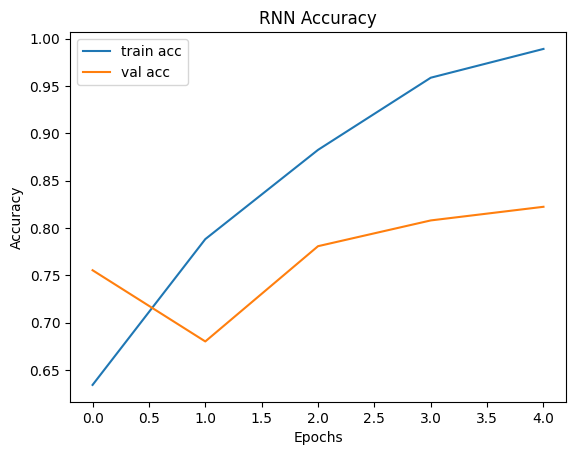

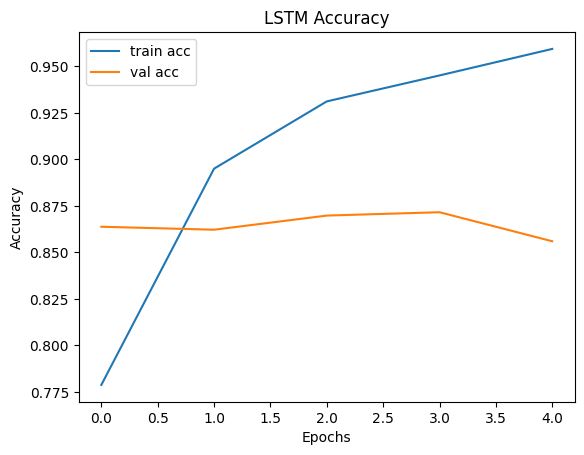

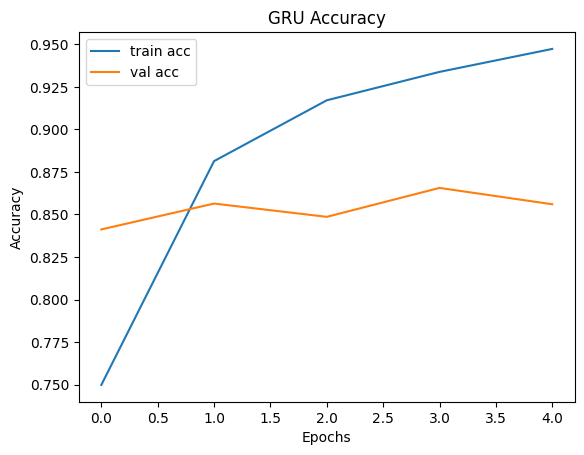

In [7]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train acc')
    plt.plot(history.history['val_accuracy'], label='val acc')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(rnn_history, "RNN Accuracy")
plot_history(lstm_history, "LSTM Accuracy")
plot_history(gru_history, "GRU Accuracy")

In [8]:
print("RNN Test Accuracy:", rnn_model.evaluate(X_test, y_test)[1])
print("LSTM Test Accuracy:", lstm_model.evaluate(X_test, y_test)[1])
print("GRU Test Accuracy:", gru_model.evaluate(X_test, y_test)[1])

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8117 - loss: 0.5599
RNN Test Accuracy: 0.8117200136184692
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8486 - loss: 0.4526
LSTM Test Accuracy: 0.8485999703407288
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8460 - loss: 0.4009
GRU Test Accuracy: 0.8459600210189819
